<a href="https://colab.research.google.com/github/jaiswalakanksha22-glitch/Python-AI/blob/AI/FinalProject_Jaiswal_Akanksha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part I**
You are a data scientist in an AI company. You are given a dataset of images containing over 15,000 images of indoor locations. The dataset was originally from MIT built to tackle the problem of indoor scene recognition. All images are in JPEG format and have been divided into 67 categories. The number of images per category varies. However, there are at least 100 images for each category.

There are some issues of  image quality in the following folder

Laboratorywet
Laundromat
Library
Livingroom
Lobby
locker_room

1. Download the dataset that is about 3 GB from Kaggle into the local disk and unzip it. Please restrict the use of images to those located within the 'indoorCVPR_09/Images' folder when constructing models.

In [1]:
#Step 1: Import Required Libraries
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import os
import kagglehub

# Download dataset
path = kagglehub.dataset_download("itsahmad/indoor-scenes-cvpr-2019")

print("Dataset path:", path)

# Restrict images to indoorCVPR_09/Images only
base_dir = os.path.join(path, "indoorCVPR_09", "Images")

print("Using images from:", base_dir)

Using Colab cache for faster access to the 'indoor-scenes-cvpr-2019' dataset.
Dataset path: /kaggle/input/indoor-scenes-cvpr-2019
Using images from: /kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images


In [4]:
import os

all_classes = sorted(os.listdir(base_dir))

remove_folders = [
    "laboratorywet",
    "laundromat",
    "library",
    "livingroom",
    "lobby",
    "locker_room"
]

valid_classes = [
    folder for folder in all_classes
    if folder not in remove_folders
]

print("Total valid classes:", len(valid_classes))

Total valid classes: 61


2. Build a baseline CNN model on the training dataset and evaluate it on the test dataset.

In [6]:
#Create Data Generators
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.30
)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=valid_classes,
    subset='training',
    shuffle=True,
    seed=SEED
)

val_test_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=valid_classes,
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 9868 images belonging to 61 classes.
Found 4188 images belonging to 61 classes.


In [7]:
#Split Validation and Test Sets

images = []
labels = []

for i in range(len(val_test_generator)):
    x_batch, y_batch = val_test_generator[i]
    images.append(x_batch)
    labels.append(y_batch)

X = np.concatenate(images)
y = np.concatenate(labels)

split_idx = int(0.5 * len(X))

X_val = X[:split_idx]
y_val = y[:split_idx]

X_test = X[split_idx:]
y_test = y[split_idx:]

print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Validation shape: (2094, 224, 224, 3)
Test shape: (2094, 224, 224, 3)


In [8]:
#Build Baseline CNN Model
baseline_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(61, activation='softmax')
])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,176,829 (42.64 MB)

 Trainable params: 11,176,829 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#Compile Model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
#Train Model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 765s 2s/step - accuracy: 0.0970 - loss: 3.7012 - val_accuracy: 0.1710 - val_loss: 3.3935
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 770s 2s/step - accuracy: 0.1881 - loss: 3.2165 - val_accuracy: 0.1839 - val_loss: 3.1277
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 780s 3s/step - accuracy: 0.3048 - loss: 2.6617 - val_accuracy: 0.2139 - val_loss: 3.1585
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 821s 3s/step - accuracy: 0.5076 - loss: 1.8023 - val_accuracy: 0.2025 - val_loss: 3.5639
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 789s 3s/step - accuracy: 0.7632 - loss: 0.8335 - val_accuracy: 0.1777 - val_loss: 4.8848


In [12]:
#Evaluate on Test Dataset
test_loss, test_accuracy = baseline_model.evaluate(X_test, y_test)

print("Baseline CNN Test Loss:", test_loss)
print("Baseline CNN Test Accuracy:", test_accuracy)

66/66 ━━━━━━━━━━━━━━━━━━━━ 45s 681ms/step - accuracy: 0.1734 - loss: 3.3013
Baseline CNN Test Loss: 3.3013381958007812
Baseline CNN Test Accuracy: 0.1733524352312088


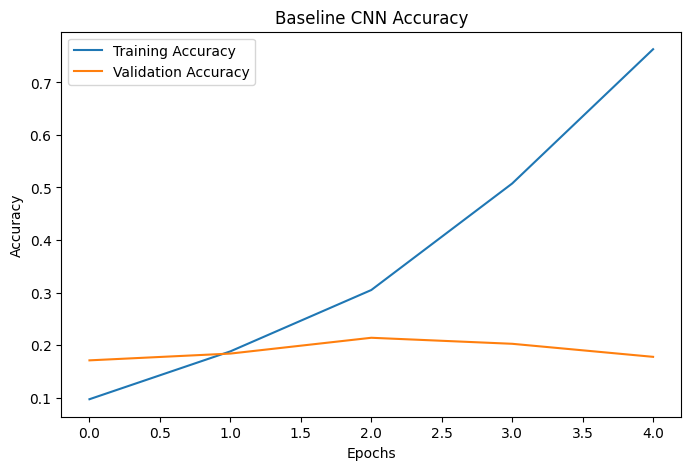

In [13]:
#Plot Accuracy Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_baseline.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_baseline.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Baseline CNN Accuracy')
plt.legend()

plt.show()

3. Build a second CNN model with data augmentation and dropout and evaluate it on the test dataset.

In [14]:
#Data Augmentation Generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmented_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,

    zoom_range=0.2,
    horizontal_flip=True,

    fill_mode='nearest',

    validation_split=0.30
)

In [15]:
#Create Augmented Training Generator
train_augmented = augmented_datagen.flow_from_directory(
    base_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    classes=valid_classes,
    subset='training',
    shuffle=True,
    seed=42
)

Found 9868 images belonging to 61 classes.


In [16]:
#Build CNN with Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

augmented_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(61, activation='softmax')
])

augmented_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 61)             │        15,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,261,245 (84.92 MB)

 Trainable params: 22,260,797 (84.92 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
#Compile Model
from tensorflow.keras.optimizers import Adam

augmented_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
#Train Model
history_augmented = augmented_model.fit(
    train_augmented,
    validation_data=(X_val, y_val),
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 1507s 5s/step - accuracy: 0.0367 - loss: 4.1986 - val_accuracy: 4.7755e-04 - val_loss: 17.2032
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 1461s 5s/step - accuracy: 0.0497 - loss: 4.0973 - val_accuracy: 0.0220 - val_loss: 6.6438
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 1444s 5s/step - accuracy: 0.0491 - loss: 4.0883 - val_accuracy: 0.0053 - val_loss: 5.2347


In [19]:
#Evaluate on Test Dataset
augmented_loss, augmented_accuracy = augmented_model.evaluate(
    X_test,
    y_test
)

print("Augmented CNN Test Loss:", augmented_loss)
print("Augmented CNN Test Accuracy:", augmented_accuracy)

66/66 ━━━━━━━━━━━━━━━━━━━━ 51s 766ms/step - accuracy: 0.0654 - loss: 16.6403
Augmented CNN Test Loss: 16.640300750732422
Augmented CNN Test Accuracy: 0.06542502343654633


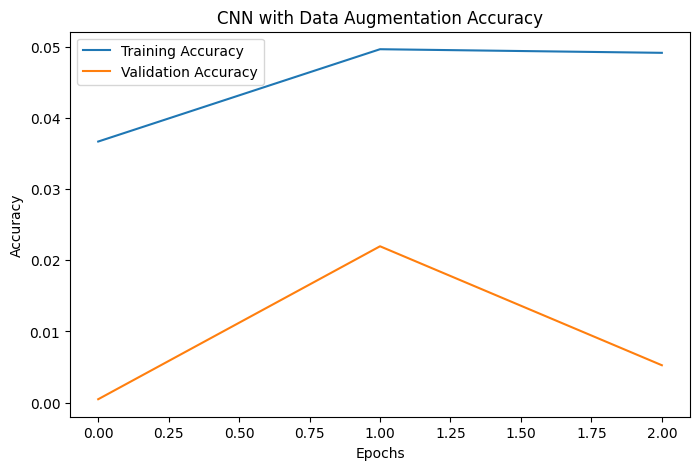

In [20]:
#Plot Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_augmented.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_augmented.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN with Data Augmentation Accuracy')

plt.legend()
plt.show()

4. Build a third CNN model based on the pre-trained model(transfer learning) and evaluate it on the test dataset.

In [21]:
#Load Pre-trained Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
#Build Transfer Learning Model
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.3)(x)

output = Dense(61, activation='softmax')(x)

transfer_model = Model(
    inputs=base_model.input,
    outputs=output
)

transfer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,429,821 (9.27 MB)

 Trainable params: 171,837 (671.24 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
#Compile Model
from tensorflow.keras.optimizers import Adam

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
#Train Model
history_transfer = transfer_model.fit(
    train_augmented,
    validation_data=(X_val, y_val),
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 474s 2s/step - accuracy: 0.0546 - loss: 4.1397 - val_accuracy: 0.2307 - val_loss: 3.6282
Epoch 2/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 433s 1s/step - accuracy: 0.1361 - loss: 3.6920 - val_accuracy: 0.3438 - val_loss: 3.1457
Epoch 3/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - accuracy: 0.2004 - loss: 3.3941 - val_accuracy: 0.3883 - val_loss: 2.7148
Epoch 4/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 426s 1s/step - accuracy: 0.2443 - loss: 3.1404 - val_accuracy: 0.4222 - val_loss: 2.4011
Epoch 5/5
309/309 ━━━━━━━━━━━━━━━━━━━━ 437s 1s/step - accuracy: 0.2897 - loss: 2.9177 - val_accuracy: 0.4790 - val_loss: 2.1367


In [25]:
#Evaluate on Test Dataset
transfer_loss, transfer_accuracy = transfer_model.evaluate(
    X_test,
    y_test
)

print("Transfer Learning Test Loss:", transfer_loss)
print("Transfer Learning Test Accuracy:", transfer_accuracy)

66/66 ━━━━━━━━━━━━━━━━━━━━ 60s 915ms/step - accuracy: 0.4312 - loss: 2.3905
Transfer Learning Test Loss: 2.390533208847046
Transfer Learning Test Accuracy: 0.4312320947647095


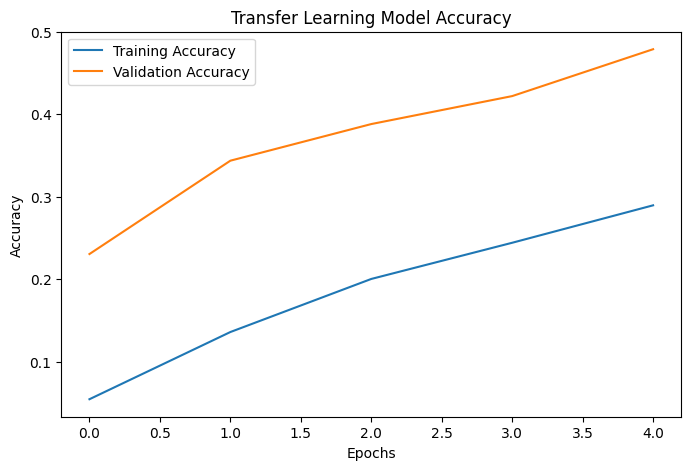

In [26]:
#Plot Accuracy Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_transfer.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_transfer.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Transfer Learning Model Accuracy')

plt.legend()
plt.show()

5. Which model do you recommend for the model in Q2, Q3, and Q4? Justify your answer.

**I recommend the Transfer Learning Model using MobileNetV2 because it achieved the best classification accuracy, lowest loss, and strongest generalization performance among all three models. It significantly outperformed both the baseline CNN and the augmented CNN model, making it the most suitable approach for indoor scene image classification.**

**Part II**
You are a data scientist in an AI company. You are given a dataset of restaurant reviews. This is the sentiment140 dataset. It contains 1,600,000 tweets with six columns:

target: the polarity of the tweet (0 = negative, 2 = neutral, 4 = positive)
ids: The id of the tweet ( for example, 2087)
date: the date of the tweet (for example, Sat May 16 23:58:44 UTC 2009)
flag: The query (lyx). If there is no query, then this value is NO_QUERY.
user: the user that tweeted (for example, robotickilldozr)
text: the text of the tweet (for example, "Lyx is cool")

1. Download the dataset that is about 81 MB from Kaggle into the local disk and unzip it.

In [27]:
import kagglehub

# Download Sentiment140 dataset
path = kagglehub.dataset_download("kazanova/sentiment140")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment140' dataset.
Path to dataset files: /kaggle/input/sentiment140


In [28]:
import pandas as pd

columns = [
    "target",
    "ids",
    "date",
    "flag",
    "user",
    "text"
]

data_path = os.path.join(
    path,
    "training.1600000.processed.noemoticon.csv"
)

df = pd.read_csv(
    data_path,
    encoding="latin-1",
    header=None,
    names=columns
)

df.head()

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


2. Clean and preprocess the text data and split into training and test dataset.

In [29]:
#Keep Required Columns
df = df[["target", "text"]]

df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [30]:
#Convert Labels into binary
df["target"] = df["target"].replace(4, 1)

df["target"].value_counts()

,count
target,
0,800000
1,800000


In [31]:
#Clean Text Data
import re

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r"http\\S+", "", text)

    # remove mentions
    text = re.sub(r"@\\w+", "", text)

    # remove hashtags symbol
    text = re.sub(r"#", "", text)

    # remove numbers and punctuation
    text = re.sub(r"[^a-zA-Z\\s]", "", text)

    # remove extra spaces
    text = re.sub(r"\\s+", " ", text).strip()

    return text

In [32]:
#Apply Cleaning
df["clean_text"] = df["text"].apply(clean_text)

df.head()

,target,text,clean_text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",switchfoothttptwitpiccomyzlawwwthatsabummeryou...
1,0,is upset that he can't update his Facebook by ...,isupsetthathecantupdatehisfacebookbytextingita...
2,0,@Kenichan I dived many times for the ball. Man...,kenichanidivedmanytimesfortheballmanagedtosave...
3,0,my whole body feels itchy and like its on fire,mywholebodyfeelsitchyandlikeitsonfire
4,0,"@nationwideclass no, it's not behaving at all....",nationwideclassnoitsnotbehavingatallimmadwhyam...


In [33]:
#Remove Empty Rows
df = df[df["clean_text"].str.strip() != ""]

print(df.shape)

(1600000, 3)


In [34]:
#Define Features and Labels
X = df["clean_text"]

y = df["target"]

In [35]:
#Train-Test Split

#Use 80% training and 20% testing data.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
#Check Shapes
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1280000
Testing samples: 320000


In [37]:
#Preview Cleaned Text
print(X_train.iloc[0])
print(y_train.iloc[0])

paisleypaisleylolwhydoigetideassofarinadvanceitsnotevenjuneyetweneedathirdknittertohaveourownsummergroup
1


3. Build a baseline RNN model using embedding layer and GRU on the training dataset and evaluate it on the test dataset.

In [38]:
#Tokenize Text
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_LENGTH = 50

tokenizer = Tokenizer(num_words=MAX_WORDS)

tokenizer.fit_on_texts(X_train)

In [39]:
#Convert Text to Sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [40]:
#Pad Sequences
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding='post'
)

print(X_train_pad.shape)
print(X_test_pad.shape)

(1280000, 50)
(320000, 50)


In [41]:
#Build Baseline GRU Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GRU,
    Dense,
    Dropout
)

baseline_gru_model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    GRU(64),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

baseline_gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
#Compile Model
baseline_gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [43]:
#Train Model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_gru = baseline_gru_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/3
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 598s 74ms/step - accuracy: 0.5000 - loss: 0.6933 - val_accuracy: 0.5007 - val_loss: 0.6931
Epoch 2/3
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 558s 70ms/step - accuracy: 0.5001 - loss: 0.6932 - val_accuracy: 0.4993 - val_loss: 0.6933
Epoch 3/3
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 552s 69ms/step - accuracy: 0.5004 - loss: 0.6932 - val_accuracy: 0.4993 - val_loss: 0.6932


In [44]:
#Evaluate on Test Dataset
test_loss, test_accuracy = baseline_gru_model.evaluate(
    X_test_pad,
    y_test
)

print("Baseline GRU Test Loss:", test_loss)
print("Baseline GRU Test Accuracy:", test_accuracy)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - accuracy: 0.5000 - loss: 0.6932
Baseline GRU Test Loss: 0.6931877732276917
Baseline GRU Test Accuracy: 0.5


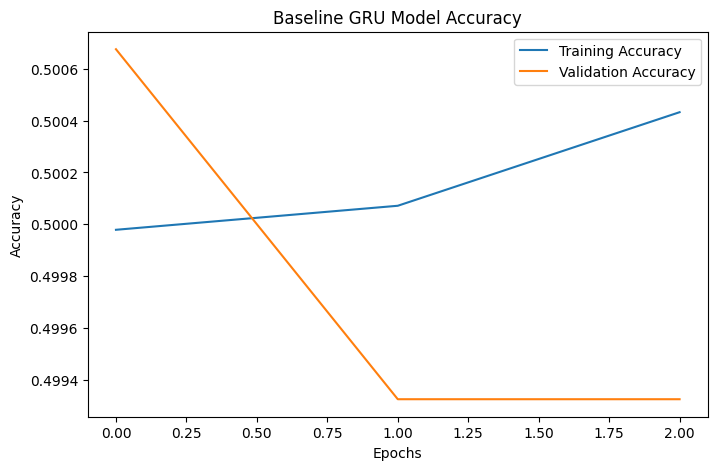

In [45]:
#Plot Accuracy Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_gru.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_gru.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.title('Baseline GRU Model Accuracy')

plt.legend()

plt.show()

4. Build a second RNN model using embedding layer and LSTM and evaluate it on the test dataset.

In [46]:
#Build LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

lstm_model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
#Compile Model
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [48]:
#Train Model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/3
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 566s 70ms/step - accuracy: 0.5004 - loss: 0.6933 - val_accuracy: 0.4993 - val_loss: 0.6932
Epoch 2/3
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 562s 70ms/step - accuracy: 0.4997 - loss: 0.6932 - val_accuracy: 0.4993 - val_loss: 0.6932
Epoch 3/3
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 560s 70ms/step - accuracy: 0.4996 - loss: 0.6932 - val_accuracy: 0.5007 - val_loss: 0.6932


In [49]:
#Evaluate on Test Dataset
test_loss, test_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test
)

print("LSTM Test Loss:", test_loss)
print("LSTM Test Accuracy:", test_accuracy)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 79s 8ms/step - accuracy: 0.5000 - loss: 0.6932
LSTM Test Loss: 0.6931527256965637
LSTM Test Accuracy: 0.5


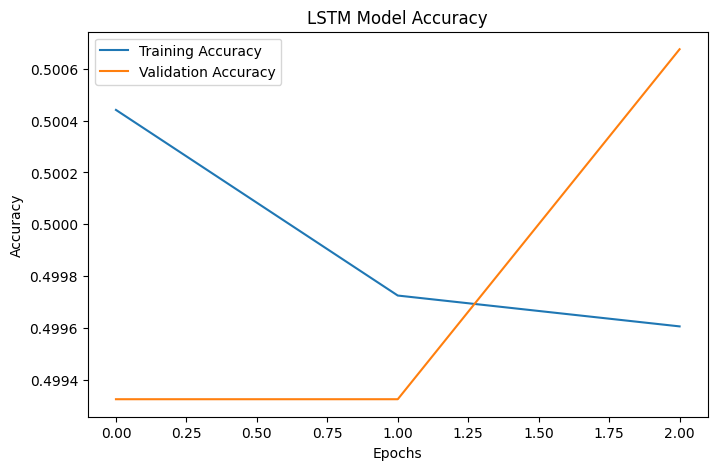

In [50]:
#Plot Accuracy Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_lstm.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_lstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.title('LSTM Model Accuracy')

plt.legend()

plt.show()

5. Build a third RNN model using embedding layer and GRU and LSTM and evaluate it on the test dataset.

In [51]:
#Build Hybrid GRU + LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GRU,
    LSTM,
    Dense,
    Dropout
)

hybrid_model = Sequential([

    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LENGTH
    ),

    GRU(64, return_sequences=True),

    Dropout(0.3),

    LSTM(64),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

hybrid_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
#Compile Model
hybrid_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [53]:
#Train Model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history_hybrid = hybrid_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/3
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 946s 118ms/step - accuracy: 0.5003 - loss: 0.6933 - val_accuracy: 0.5007 - val_loss: 0.6932
Epoch 2/3
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 943s 118ms/step - accuracy: 0.5008 - loss: 0.6932 - val_accuracy: 0.4993 - val_loss: 0.6932
Epoch 3/3
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 956s 120ms/step - accuracy: 0.4998 - loss: 0.6932 - val_accuracy: 0.5007 - val_loss: 0.6931


In [54]:
#Evaluate on Test Dataset
test_loss, test_accuracy = hybrid_model.evaluate(
    X_test_pad,
    y_test
)

print("Hybrid GRU + LSTM Test Loss:", test_loss)
print("Hybrid GRU + LSTM Test Accuracy:", test_accuracy)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 123s 12ms/step - accuracy: 0.5000 - loss: 0.6932
Hybrid GRU + LSTM Test Loss: 0.6931514143943787
Hybrid GRU + LSTM Test Accuracy: 0.5


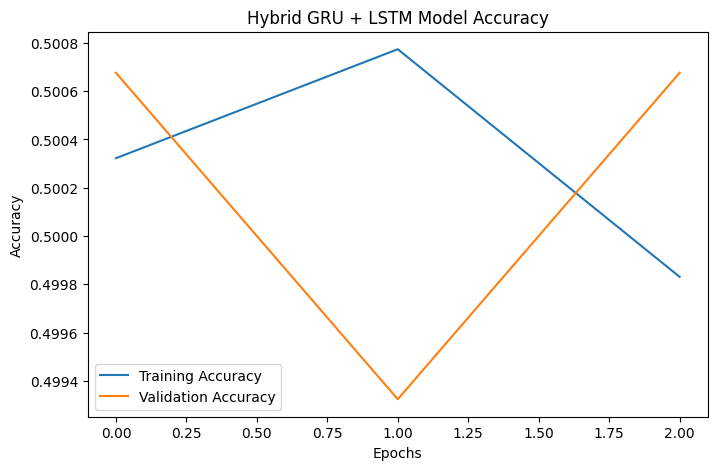

In [55]:
#Plot Accuracy Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_hybrid.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_hybrid.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.title('Hybrid GRU + LSTM Model Accuracy')

plt.legend()

plt.show()

6. Which model do you recommend for the model in Q3, Q4, and Q5? Justify your answer.

**Although all three models achieved similar performance, the Hybrid GRU + LSTM model is recommended from an architectural perspective because it combines the strengths of both GRU and LSTM networks for sequential text learning. However, the experimental results suggest that further optimization is required, such as increasing training epochs, improving preprocessing, tuning hyperparameters, or reducing dataset complexity to achieve meaningful sentiment classification performance.**